# Marketing Funnel & Conversion Performance Analysis

**Business context:** The growth/marketing team wants to know where prospects drop out of the
funnel (Impression → Click → Lead → Signup → Customer), which acquisition channels convert
efficiently vs. just generate volume, and where to reallocate budget to improve lead-to-customer
conversion.

**This notebook covers:**
1. Data overview
2. Overall funnel & stage-to-stage conversion rates
3. Biggest drop-off points
4. Channel performance ranking (CVR, CAC)
5. Conversion trend over time
6. Device breakdown
7. Key findings & recommendations

> Dataset: 240 days of daily channel-level funnel events across 6 acquisition channels
> (synthetic, generated with realistic channel-specific conversion rates — see
> `src/generate_data.py`). All numbers below are computed live in this notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)

STAGES = ["impressions", "clicks", "leads", "signups", "customers"]
STAGE_LABELS = ["Impression", "Click", "Lead", "Signup", "Customer"]

df = pd.read_csv("../data/funnel_events.csv", parse_dates=["date"])
df.head()


## 1. Data Overview

In [2]:
print(f"Rows: {len(df):,}   Date range: {df.date.min().date()} to {df.date.max().date()}")
print(f"Channels: {df.channel.unique().tolist()}")
df.dtypes


Rows: 1,440   Date range: 2026-01-01 to 2026-08-28
Channels: ['Paid Search', 'Paid Social', 'Organic Search', 'Email', 'Referral', 'Direct']


## 2. Overall Funnel & Stage-to-Stage Conversion

     stage    count  pct_of_total  pct_of_previous_stage
Impression 11050187        100.00                    NaN
     Click   431828          3.91                   3.91
      Lead   131010          1.19                  30.34
    Signup    74458          0.67                  56.83
  Customer    31122          0.28                  41.80


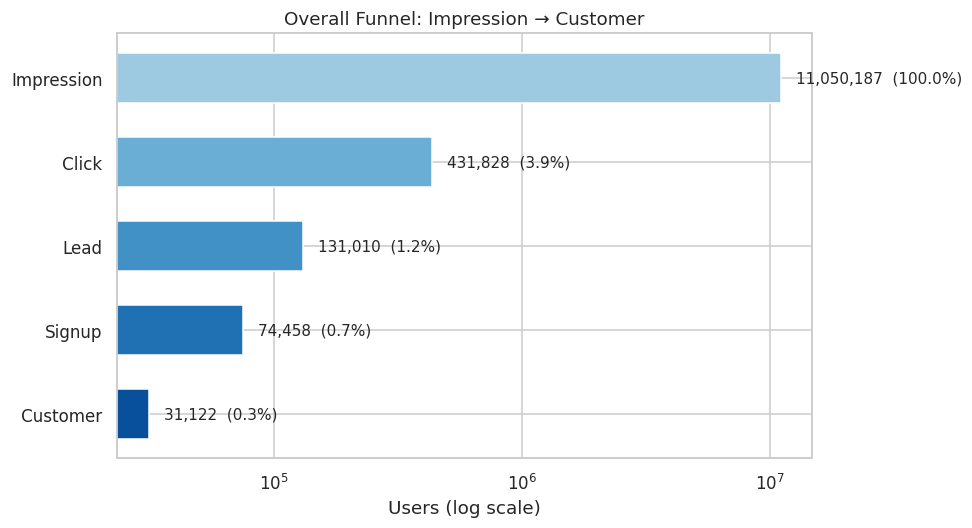

In [3]:
totals = df[STAGES].sum()
conv_from_top = (totals / totals.iloc[0] * 100).round(2)
step_conv = (totals / totals.shift(1) * 100).round(2)

funnel_df = pd.DataFrame({
    "stage": STAGE_LABELS,
    "count": totals.values,
    "pct_of_total": conv_from_top.values,
    "pct_of_previous_stage": step_conv.values,
})
print(funnel_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette("Blues", len(STAGE_LABELS) + 2)[2:]
y_pos = np.arange(len(STAGE_LABELS))[::-1]
ax.barh(y_pos, funnel_df["count"], color=colors, height=0.6)
ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(STAGE_LABELS)
for y, c, pct in zip(y_pos, funnel_df["count"], funnel_df["pct_of_total"]):
    ax.text(c * 1.15, y, f"{c:,.0f}  ({pct:.1f}%)", va="center", fontsize=10)
ax.set_xlabel("Users (log scale)")
ax.set_title("Overall Funnel: Impression → Customer")
plt.tight_layout()
plt.show()


**Key read:** of every ~10,000 impressions, roughly **390 click**, **12 become
leads**, **7 sign up**, and **~3 become paying customers** — an overall Impression→Customer
conversion rate of well under 1%. That's typical for a broad-reach paid+organic mix, but it
means small improvements at any stage compound significantly downstream.

## 3. Biggest Drop-off Points

from_stage to_stage  users_lost  dropoff_rate_pct
Impression    Click    10618359             96.09
     Click     Lead      300818             69.66
    Signup Customer       43336             58.20
      Lead   Signup       56552             43.17


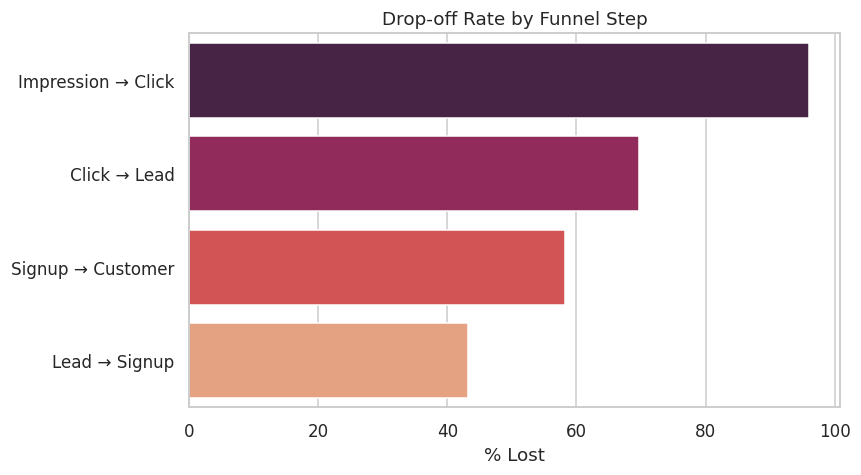

In [4]:
drops = []
for i in range(len(STAGES) - 1):
    lost = totals[STAGES[i]] - totals[STAGES[i + 1]]
    rate = lost / totals[STAGES[i]] * 100
    drops.append({"from_stage": STAGE_LABELS[i], "to_stage": STAGE_LABELS[i + 1],
                   "users_lost": int(lost), "dropoff_rate_pct": round(rate, 2)})
drops_df = pd.DataFrame(drops).sort_values("dropoff_rate_pct", ascending=False)
print(drops_df.to_string(index=False))

plt.figure(figsize=(8, 4.5))
labels = drops_df["from_stage"] + " → " + drops_df["to_stage"]
sns.barplot(x=drops_df["dropoff_rate_pct"], y=labels, palette="rocket")
plt.xlabel("% Lost")
plt.ylabel("")
plt.title("Drop-off Rate by Funnel Step")
plt.tight_layout()
plt.show()


**Key read:** the **Impression → Click** step loses the most users by far (~96%),
which is expected for top-of-funnel — but the **Click → Lead** step loses ~70% of an already
warm audience, making it the highest-leverage step to optimize (better landing pages, clearer
CTAs, faster load times).

## 4. Channel Performance

       channel  impressions  clicks  leads  signups  customers  spend_usd  overall_cvr  click_through_rate  lead_rate  signup_rate  close_rate  cac_usd
      Referral       436236   34726  14513     9880       5045       0.00        1.156                7.96      41.79        68.08       51.06     0.00
        Direct       736889   66395  25378    15841       7669       0.00        1.041                9.01      38.22        62.42       48.41     0.00
         Email      1158313   74549  25967    15724       7138    1737.55        0.616                6.44      34.83        60.55       45.40     0.24
   Paid Search      2629264  118499  35516    19498       6783   47326.68        0.258                4.51      29.97        54.90       34.79     6.98
Organic Search      2055051   65722  18356     9091       3488       0.00        0.170                3.20      27.93        49.53       38.37     0.00
   Paid Social      4034434   71937  11280     4424        999   48413.23        0.025  

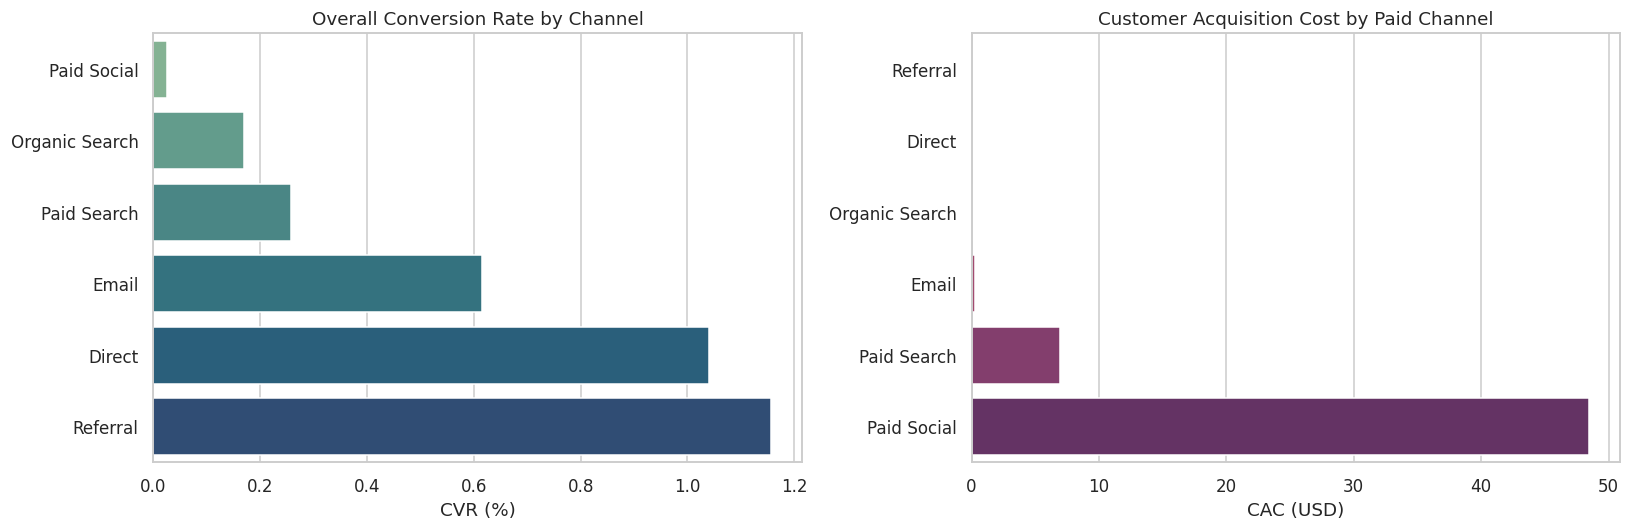

In [5]:
g = df.groupby("channel")[STAGES + ["spend_usd"]].sum()
g["overall_cvr"] = (g["customers"] / g["impressions"] * 100).round(3)
g["click_through_rate"] = (g["clicks"] / g["impressions"] * 100).round(2)
g["lead_rate"] = (g["leads"] / g["clicks"] * 100).round(2)
g["signup_rate"] = (g["signups"] / g["leads"] * 100).round(2)
g["close_rate"] = (g["customers"] / g["signups"] * 100).round(2)
g["cac_usd"] = (g["spend_usd"] / g["customers"].replace(0, np.nan)).round(2)
perf = g.sort_values("overall_cvr", ascending=False).reset_index()
print(perf.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=perf.sort_values("overall_cvr"), y="channel", x="overall_cvr", ax=axes[0], palette="crest")
axes[0].set_title("Overall Conversion Rate by Channel")
axes[0].set_xlabel("CVR (%)")
axes[0].set_ylabel("")

cac_df = perf[perf["cac_usd"].notna()].sort_values("cac_usd")
sns.barplot(data=cac_df, y="channel", x="cac_usd", ax=axes[1], palette="flare")
axes[1].set_title("Customer Acquisition Cost by Paid Channel")
axes[1].set_xlabel("CAC (USD)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


**Key read:** **Referral** and **Direct** convert best and cost nothing to
acquire directly. **Paid Social** drives the most impressions but has both the **lowest CVR**
and by far the **highest CAC (~$48)** — it's a volume channel, not an efficiency channel, in
this dataset. **Paid Search** sits in between: meaningful CAC (~$7) but a healthier CVR and
solid absolute customer volume.

## 5. Conversion Rate Trend Over Time

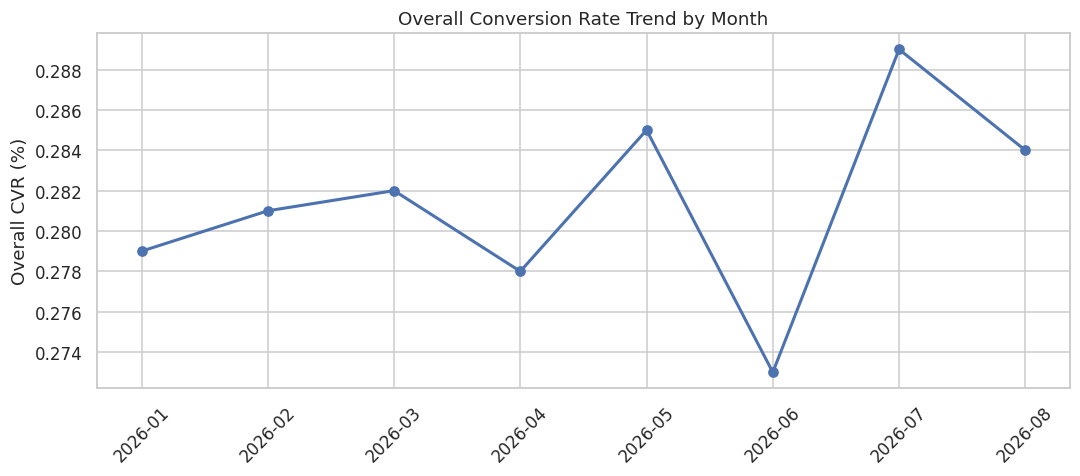

In [6]:
m = df.copy()
m["month"] = m["date"].dt.to_period("M").astype(str)
trend = m.groupby("month")[STAGES].sum()
trend["cvr"] = (trend["customers"] / trend["impressions"] * 100).round(3)
trend = trend.reset_index()

plt.figure(figsize=(10, 4.5))
plt.plot(trend["month"], trend["cvr"], marker="o", linewidth=2)
plt.xticks(rotation=45)
plt.ylabel("Overall CVR (%)")
plt.title("Overall Conversion Rate Trend by Month")
plt.tight_layout()
plt.show()


## 6. Device Breakdown

 device  impressions  clicks  leads  signups  customers   cvr
 Mobile      6269746  251794  76918    43868      18448 0.294
Desktop      3939963  150814  45615    25819      10658 0.271
 Tablet       840478   29220   8477     4771       2016 0.240


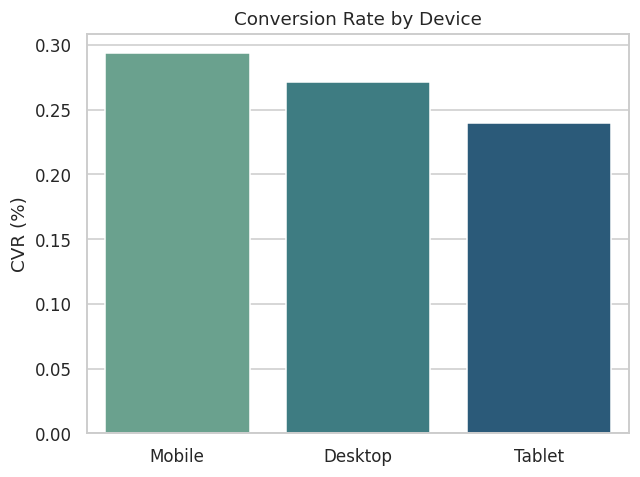

In [7]:
dev = df.groupby("device")[STAGES].sum()
dev["cvr"] = (dev["customers"] / dev["impressions"] * 100).round(3)
dev = dev.reset_index().sort_values("cvr", ascending=False)
print(dev.to_string(index=False))

plt.figure(figsize=(6, 4.5))
sns.barplot(data=dev, x="device", y="cvr", palette="crest")
plt.title("Conversion Rate by Device")
plt.ylabel("CVR (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()


**Key read:** **Mobile** converts best, ahead of Desktop and Tablet — worth
confirming the mobile checkout/signup flow is being prioritized in QA and design, since it's
carrying the most volume *and* converting best.

## 7. Key Findings & Recommendations

**Findings**
- Overall Impression→Customer conversion is **~0.28%**, with the **Click→Lead** step
  (~70% drop-off) being the highest-leverage optimization point after the natural top-of-funnel
  loss.
- **Referral and Direct** are the most efficient channels (highest CVR, $0 direct acquisition
  cost); **Paid Social** is the least efficient (lowest CVR, highest CAC ~$48/customer).
- **Paid Search** is a reasonable middle ground: real cost (~$7 CAC) but healthy conversion and
  strong volume.
- **Mobile** converts better than Desktop or Tablet despite carrying the most traffic.
- Conversion rate has been **relatively flat month-over-month**, suggesting recent growth has
  come from volume, not efficiency gains — an opportunity, since even small CVR lifts compound
  across a large top-of-funnel.

**Recommendations**
1. **Reallocate a portion of Paid Social spend** toward Paid Search and Email, which convert
   more efficiently, or add stronger audience qualification/creative testing to Paid Social
   before scaling it further.
2. **Prioritize Click→Lead optimization**: audit landing pages, form length, and page speed for
   the channels driving the most clicks (Paid Search, Paid Social) since this is the single
   biggest addressable drop-off after top-of-funnel.
3. **Invest in referral mechanics** (referral programs, incentives) given it's already the
   highest-converting, zero-CAC channel — small increases in referral volume are high-ROI.
4. **Protect and refine the mobile experience** given it already out-converts other devices and
   likely carries the majority of traffic.
5. **Set a CVR-improvement goal, not just a volume goal**, for the next quarter — since CVR has
   been flat while volume grew, there's clear headroom for efficiency-focused work.
